### Imports

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import random
from matplotlib.image import imread
from PIL import Image
import cv2
import shutil
import numpy as np
from tqdm import tqdm
from collections import Counter
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.utils import class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adamax, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import warnings
warnings.filterwarnings('ignore')

In [3]:
pharaohs_path= Path("/kaggle/input/pharaohs150-noaug-clean/Final")
classes = os.listdir(pharaohs_path)

In [4]:
print(classes)
print(len(classes))

['Seti I', 'Ramesses II and Goddess', 'Amenhotep III and God Re-Horakhty', 'Merenptah and Goddess Mut', 'Khasekhem', 'Ahmose I', 'Ptolemy II Philadelphus', 'Amenhotep II', 'Sobekhotep IV', 'Isis (Goddess) with her child', 'Amun-Ra (God)', 'Arsinoe III (Queen, daughter of Ptolemy I and wife of Ptolemy II)', 'Neferkare Shabaka', 'Amun (God)', 'Ramesses II and God Ptah and Goddess Sekhment', 'Senwosret III', 'Psusennes I', 'Senwosret I', 'Ptolemy I Soter', 'Khafre', 'Khufu', 'Nofret (Queen, possibly Nofret II, wife of Senusret II)', 'Rameses II and Hauron', 'Raneferef', 'Anubis (God)', 'Ramesses II and Goddess Anath', 'Menkaure and his wife (likely Queen Khamerernebty II)', 'Hormheb', 'Ramesses II and Goddesses Isis and Hathor', 'Teti', 'Thutmose IV and his mother Tiaa', 'Ptolemy III Euergetes', 'Senwosret IV', 'Tutankhamun and consort Ankhsenamun', 'Osiris (God)', 'Serapis (God)', 'Menkuare', 'Ramesses III and Gods Horus and Seth', 'Ramesses II and God Ptah and a Goddess', 'Achoris', 'Sn

In [ ]:
def count_ext(root, ext):
    ext = ext.lower()
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() == ext)

print("jpeg:", count_ext(pharaohs_path, ".jpeg"))
print("jpg :", count_ext(pharaohs_path, ".jpg"))

jpeg: 0
jpg : 8068


### Helper Functions

In [6]:
IMG_EXTS = {".jpg", ".jpeg"}

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def count_images_recursive(path: Path):
    return sum(1 for p in path.rglob("*") if p.suffix.lower() in IMG_EXTS)

def count_images_in_dir(path: Path):
    return sum(1 for p in path.iterdir() if p.suffix.lower() in IMG_EXTS)

In [7]:
def make_df(pharaohs_path: Path):
    rows = []

    for class_dir in list_subdirs(pharaohs_path):
        pharaoh_name = class_dir.name
        for p in class_dir.iterdir():
            if p.suffix.lower() in IMG_EXTS:
                rows.append({"label": str(pharaoh_name)  , "path": str(p)})

    df = pd.DataFrame(rows, columns=["label", "path"])
    return df

In [9]:
df= make_df(pharaohs_path)
df.sample(10)

,label,path
821,Amenhotep III,/kaggle/input/pharaohs150-noaug-clean/Final/Am...
1846,Hatshepsut,/kaggle/input/pharaohs150-noaug-clean/Final/Ha...
3571,Mut (Goddess),/kaggle/input/pharaohs150-noaug-clean/Final/Mu...
488,Amenemhat III,/kaggle/input/pharaohs150-noaug-clean/Final/Am...
2162,Hormheb,/kaggle/input/pharaohs150-noaug-clean/Final/Ho...
6304,Serapis (God),/kaggle/input/pharaohs150-noaug-clean/Final/Se...
1984,Hor I,/kaggle/input/pharaohs150-noaug-clean/Final/Ho...
7875,Userkaf,/kaggle/input/pharaohs150-noaug-clean/Final/Us...
5897,Sekhmet (Goddess),/kaggle/input/pharaohs150-noaug-clean/Final/Se...
6378,Serapis (God),/kaggle/input/pharaohs150-noaug-clean/Final/Se...


In [10]:
print("Dataframe shape:", df.shape)

Dataframe shape: (8068, 2)


### Preprocessing

<Axes: xlabel='label', ylabel='count'>

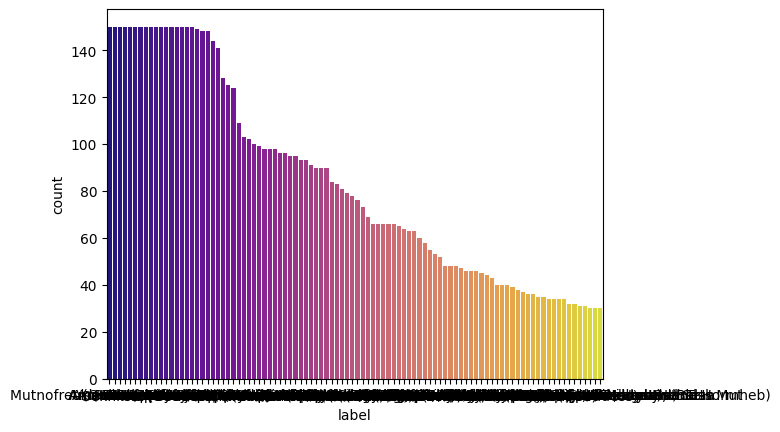

In [11]:
sns.countplot(data=df,x='label',palette='plasma',order=df['label'].value_counts().index )

In [12]:
df['label'].value_counts()

label
Akhenaton                                   150
Amenhotep II                                150
Amenemhat III                               150
Amenhotep III                               150
Khafre                                      150
                                           ... 
Ramesses III and Gods Horus and Seth         31
Ramesess II and God Amun and Goddess Mut     31
Isis (Goddess)                               30
Ptolemy III Euergetes                        30
Thutmose IV and his mother Tiaa              30
Name: count, Length: 96, dtype: int64

In [13]:
def show(title, img):
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def load_bgr(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read {path}")
    return img_bgr

def bgr_to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

In [14]:
image_size = 256
def resize(image, size=image_size):
  return cv2.resize(image,(size,size), interpolation=cv2.INTER_AREA)
    
def normalize(image):
  return image/255.0

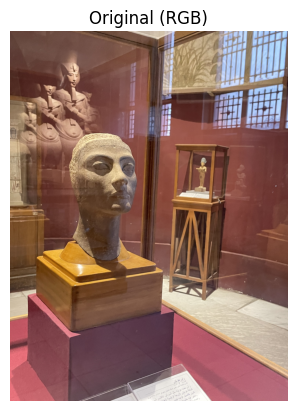

Original shape: (4032, 3024, 3) dtype: uint8


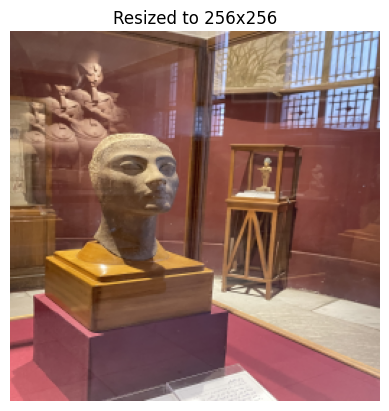

Resized shape: (256, 256, 3)


In [15]:
sample_row = df.iloc[3903]
sample_path = sample_row["path"]
sample_label = sample_row["label"]

image_BGR = load_bgr(sample_path)
image_RGB = bgr_to_rgb(image_BGR)

show("Original (RGB)", image_RGB)
print("Original shape:", image_RGB.shape, "dtype:", image_RGB.dtype)

image_resized= resize(image_RGB,image_size)
show(f"Resized to {image_size}x{image_size}", image_resized)
print("Resized shape:", image_resized.shape)


In [ ]:
def preprocess_image(path, size=image_size):
    image_BGR = load_bgr(path)
    image_RGB = bgr_to_rgb(image_BGR)
    image_resized = resize(image_RGB, size)

    image_resized = image_resized.astype(np.float32)
    return image_resized

In [17]:
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

class TFDataset:
    def __init__(self, df, batch_size=BATCH_SIZE, shuffle=True, image_size=image_size):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        def _py_preprocess(path_str):
            path_str = path_str.decode("utf-8")
            img = preprocess_image(
                path_str,
                size=self.image_size,
            )
            img = preprocess_input(img) 
            return img.astype("float32")

        img = tf.numpy_function(_py_preprocess, [path], tf.float32)
        img.set_shape((self.image_size, self.image_size, 3))
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label"].values.astype("float32")

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size)
        ds = ds.prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

### Model

#### Split

In [18]:
df.shape[0]

8068

In [19]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.3,
    stratify=temp_df["label"],
    random_state=42
)

In [20]:
train_df['label'].value_counts()

label
Akhenaton                                   120
Senwosret I                                 120
Mentuhotep II                               120
Tutankhamun                                 120
Hatshepsut                                  120
                                           ... 
Ramesess II and God Amun and Goddess Mut     25
Ramesses III and Gods Horus and Seth         25
Ptolemy III Euergetes                        24
Isis (Goddess)                               24
Thutmose IV and his mother Tiaa              24
Name: count, Length: 96, dtype: int64

In [21]:
print("Train size:", train_df.shape[0])
print("Test size:", test_df['label'].shape[0])
print("Valid size:", valid_df['label'].shape[0])

Train size: 6454
Test size: 485
Valid size: 1129


#### Label Encoding

In [22]:
encoder = LabelEncoder()

train_df['label'] = encoder.fit_transform(train_df['label'])
test_df['label'] = encoder.transform(test_df['label'])
valid_df['label'] = encoder.transform(valid_df['label'])

In [23]:
counts = train_df['label'].value_counts()
counts.index = encoder.inverse_transform(counts.index.astype(int))

counts

Akhenaton                                   120
Senwosret I                                 120
Mentuhotep II                               120
Tutankhamun                                 120
Hatshepsut                                  120
                                           ... 
Ramesess II and God Amun and Goddess Mut     25
Ramesses III and Gods Horus and Seth         25
Ptolemy III Euergetes                        24
Isis (Goddess)                               24
Thutmose IV and his mother Tiaa              24
Name: count, Length: 96, dtype: int64

#### Class Weights

In [24]:
train_df['label'].values

array([ 2, 72, 37, ...,  8, 92,  0])

In [25]:
y = train_df['label'] 

classes = np.unique(y)
class_weights_array = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weights = dict(zip(classes, class_weights_array))

print(class_weights)

{np.int64(0): np.float64(0.9085022522522522), np.int64(1): np.float64(2.4010416666666665), np.int64(2): np.float64(0.5602430555555555), np.int64(3): np.float64(1.2684748427672956), np.int64(4): np.float64(2.3182471264367814), np.int64(5): np.float64(1.4615036231884058), np.int64(6): np.float64(0.5602430555555555), np.int64(7): np.float64(0.5602430555555555), np.int64(8): np.float64(0.5602430555555555), np.int64(9): np.float64(1.0843413978494623), np.int64(10): np.float64(0.8619123931623932), np.int64(11): np.float64(1.2928685897435896), np.int64(12): np.float64(2.1009114583333335), np.int64(13): np.float64(1.034294871794872), np.int64(14): np.float64(2.1686827956989245), np.int64(15): np.float64(1.222348484848485), np.int64(16): np.float64(0.9209474885844748), np.int64(17): np.float64(1.7238247863247864), np.int64(18): np.float64(1.8170045045045045), np.int64(19): np.float64(0.5649509803921569), np.int64(20): np.float64(1.0671296296296295), np.int64(21): np.float64(0.5602430555555555),

In [27]:
train_data = TFDataset(
    train_df,
    batch_size=BATCH_SIZE,
    shuffle=True,
    image_size=256)

val_data = TFDataset(
    valid_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=256
)

In [28]:
print("Number of samples:", len(train_data.df))
print("Number of batches:", len(train_data))

Number of samples: 6454
Number of batches: 202


#### Build and Train

In [29]:
IMG_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 96

In [30]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [31]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 24,792,800 (94.58 MB)

 Trainable params: 1,205,088 (4.60 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

#### Stage 1

In [32]:
base_model.trainable = True 

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_data.dataset,
    validation_data=val_data.dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
 55/202 ━━━━━━━━━━━━━━━━━━━━ 9:08 4s/step - accuracy: 0.0155 - loss: 4.8136

Corrupt JPEG data: 10053 extraneous bytes before marker 0xee


 65/202 ━━━━━━━━━━━━━━━━━━━━ 8:25 4s/step - accuracy: 0.0168 - loss: 4.7929

Corrupt JPEG data: 10776 extraneous bytes before marker 0xe2


202/202 ━━━━━━━━━━━━━━━━━━━━ 877s 4s/step - accuracy: 0.0362 - loss: 4.5997 - val_accuracy: 0.3959 - val_loss: 3.5414 - learning_rate: 1.0000e-04
Epoch 2/20
114/202 ━━━━━━━━━━━━━━━━━━━━ 5:40 4s/step - accuracy: 0.2125 - loss: 3.7023

...

202/202 ━━━━━━━━━━━━━━━━━━━━ 883s 4s/step - accuracy: 0.9389 - loss: 0.1919 - val_accuracy: 0.9380 - val_loss: 0.2875 - learning_rate: 1.0000e-04
Epoch 20/20


Corrupt JPEG data: 10053 extraneous bytes before marker 0xee


166/202 ━━━━━━━━━━━━━━━━━━━━ 2:11 4s/step - accuracy: 0.9492 - loss: 0.1814

Corrupt JPEG data: 10776 extraneous bytes before marker 0xe2


202/202 ━━━━━━━━━━━━━━━━━━━━ 882s 4s/step - accuracy: 0.9483 - loss: 0.1831 - val_accuracy: 0.9362 - val_loss: 0.2805 - learning_rate: 1.0000e-04


#### Stage 2

### Evaluation

Text(0.5, 1.0, 'Model Accuracy during Training')

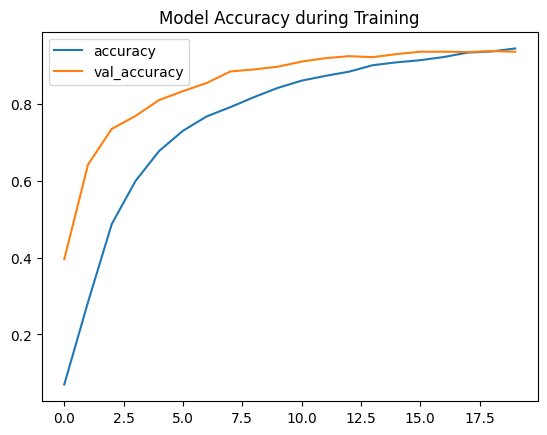

In [33]:
losses=pd.DataFrame(history.history)

losses[['accuracy','val_accuracy']].plot()
plt.title('Model Accuracy during Training')

Text(0.5, 1.0, 'Model Loss during Training')

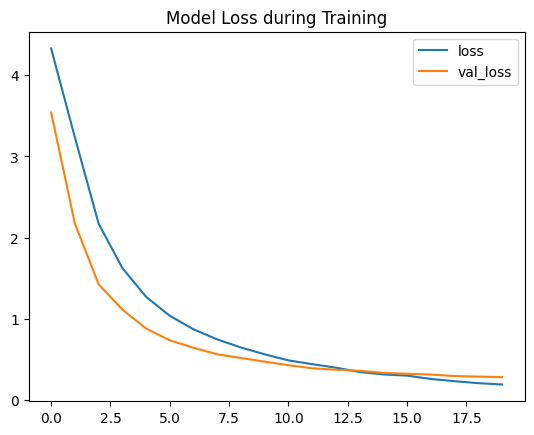

In [34]:
losses[['loss','val_loss']].plot()
plt.title('Model Loss during Training')

In [37]:
test_data = TFDataset(
    test_df,
    batch_size=BATCH_SIZE,
    shuffle=False,
    image_size=image_size,
)

In [38]:
print("Number of samples:", len(test_data.df))
print("Number of batches:", len(test_data))

Number of samples: 485
Number of batches: 16


In [39]:
y_true = np.concatenate([y for x, y in val_data.dataset], axis=0)
y_pred = np.argmax(model.predict(val_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

36/36 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        13
         1.0       0.80      0.80      0.80         5
         2.0       0.94      0.81      0.87        21
         3.0       1.00      0.89      0.94         9
         4.0       0.71      1.00      0.83         5
         5.0       1.00      1.00      1.00         8
         6.0       1.00      0.95      0.98        21
         7.0       0.83      0.95      0.89        21
         8.0       1.00      0.81      0.89        21
         9.0       0.92      1.00      0.96        11
        10.0       0.93      1.00      0.97        14
        11.0       1.00      1.00      1.00         9
        12.0       0.86      1.00      0.92         6
        13.0       1.00      0.91      0.95        11
        14.0       0.83      1.00      0.91         5
        15.0       0.83      1.00      0.91        10
        16.0       1.00      0.69      0.

#### Test Inference

In [40]:
y_true = np.concatenate([y for x, y in test_data.dataset], axis=0)
y_pred = np.argmax(model.predict(test_data.dataset), axis=1)

print(classification_report(y_true, y_pred))

Corrupt JPEG data: 10596 extraneous bytes before marker 0xee
Corrupt JPEG data: 10596 extraneous bytes before marker 0xee


16/16 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         6
         1.0       1.00      1.00      1.00         2
         2.0       0.90      1.00      0.95         9
         3.0       1.00      1.00      1.00         4
         4.0       0.67      1.00      0.80         2
         5.0       0.80      1.00      0.89         4
         6.0       1.00      1.00      1.00         9
         7.0       0.73      0.89      0.80         9
         8.0       0.90      1.00      0.95         9
         9.0       1.00      1.00      1.00         5
        10.0       1.00      1.00      1.00         6
        11.0       1.00      1.00      1.00         4
        12.0       0.67      1.00      0.80         2
        13.0       1.00      1.00      1.00         5
        14.0       1.00      1.00      1.00         2
        15.0       1.00      1.00      1.00         4
        16.0       1.00      0.80      0.8

In [41]:
report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0.0,1.000000,1.000000,1.000000,6.000000
1.0,1.000000,1.000000,1.000000,2.000000
2.0,0.900000,1.000000,0.947368,9.000000
3.0,1.000000,1.000000,1.000000,4.000000
4.0,0.666667,1.000000,0.800000,2.000000
...,...,...,...,...
94.0,0.900000,1.000000,0.947368,9.000000
95.0,0.857143,1.000000,0.923077,6.000000
accuracy,0.931959,0.931959,0.931959,0.931959
macro avg,0.927008,0.920689,0.915344,485.000000


In [42]:
print("Overall precision:", report["weighted avg"]["precision"])
print("Overall recall:", report["weighted avg"]["recall"])
print("Overall f1-score:", report["weighted avg"]["f1-score"])
print("Overall accuracy:",report["accuracy"])

Overall precision: 0.9391683402508144
Overall recall: 0.931958762886598
Overall f1-score: 0.9301223186078441
Overall accuracy: 0.931958762886598


#### Test (Unseen Samples)

Corrupt JPEG data: 10596 extraneous bytes before marker 0xee


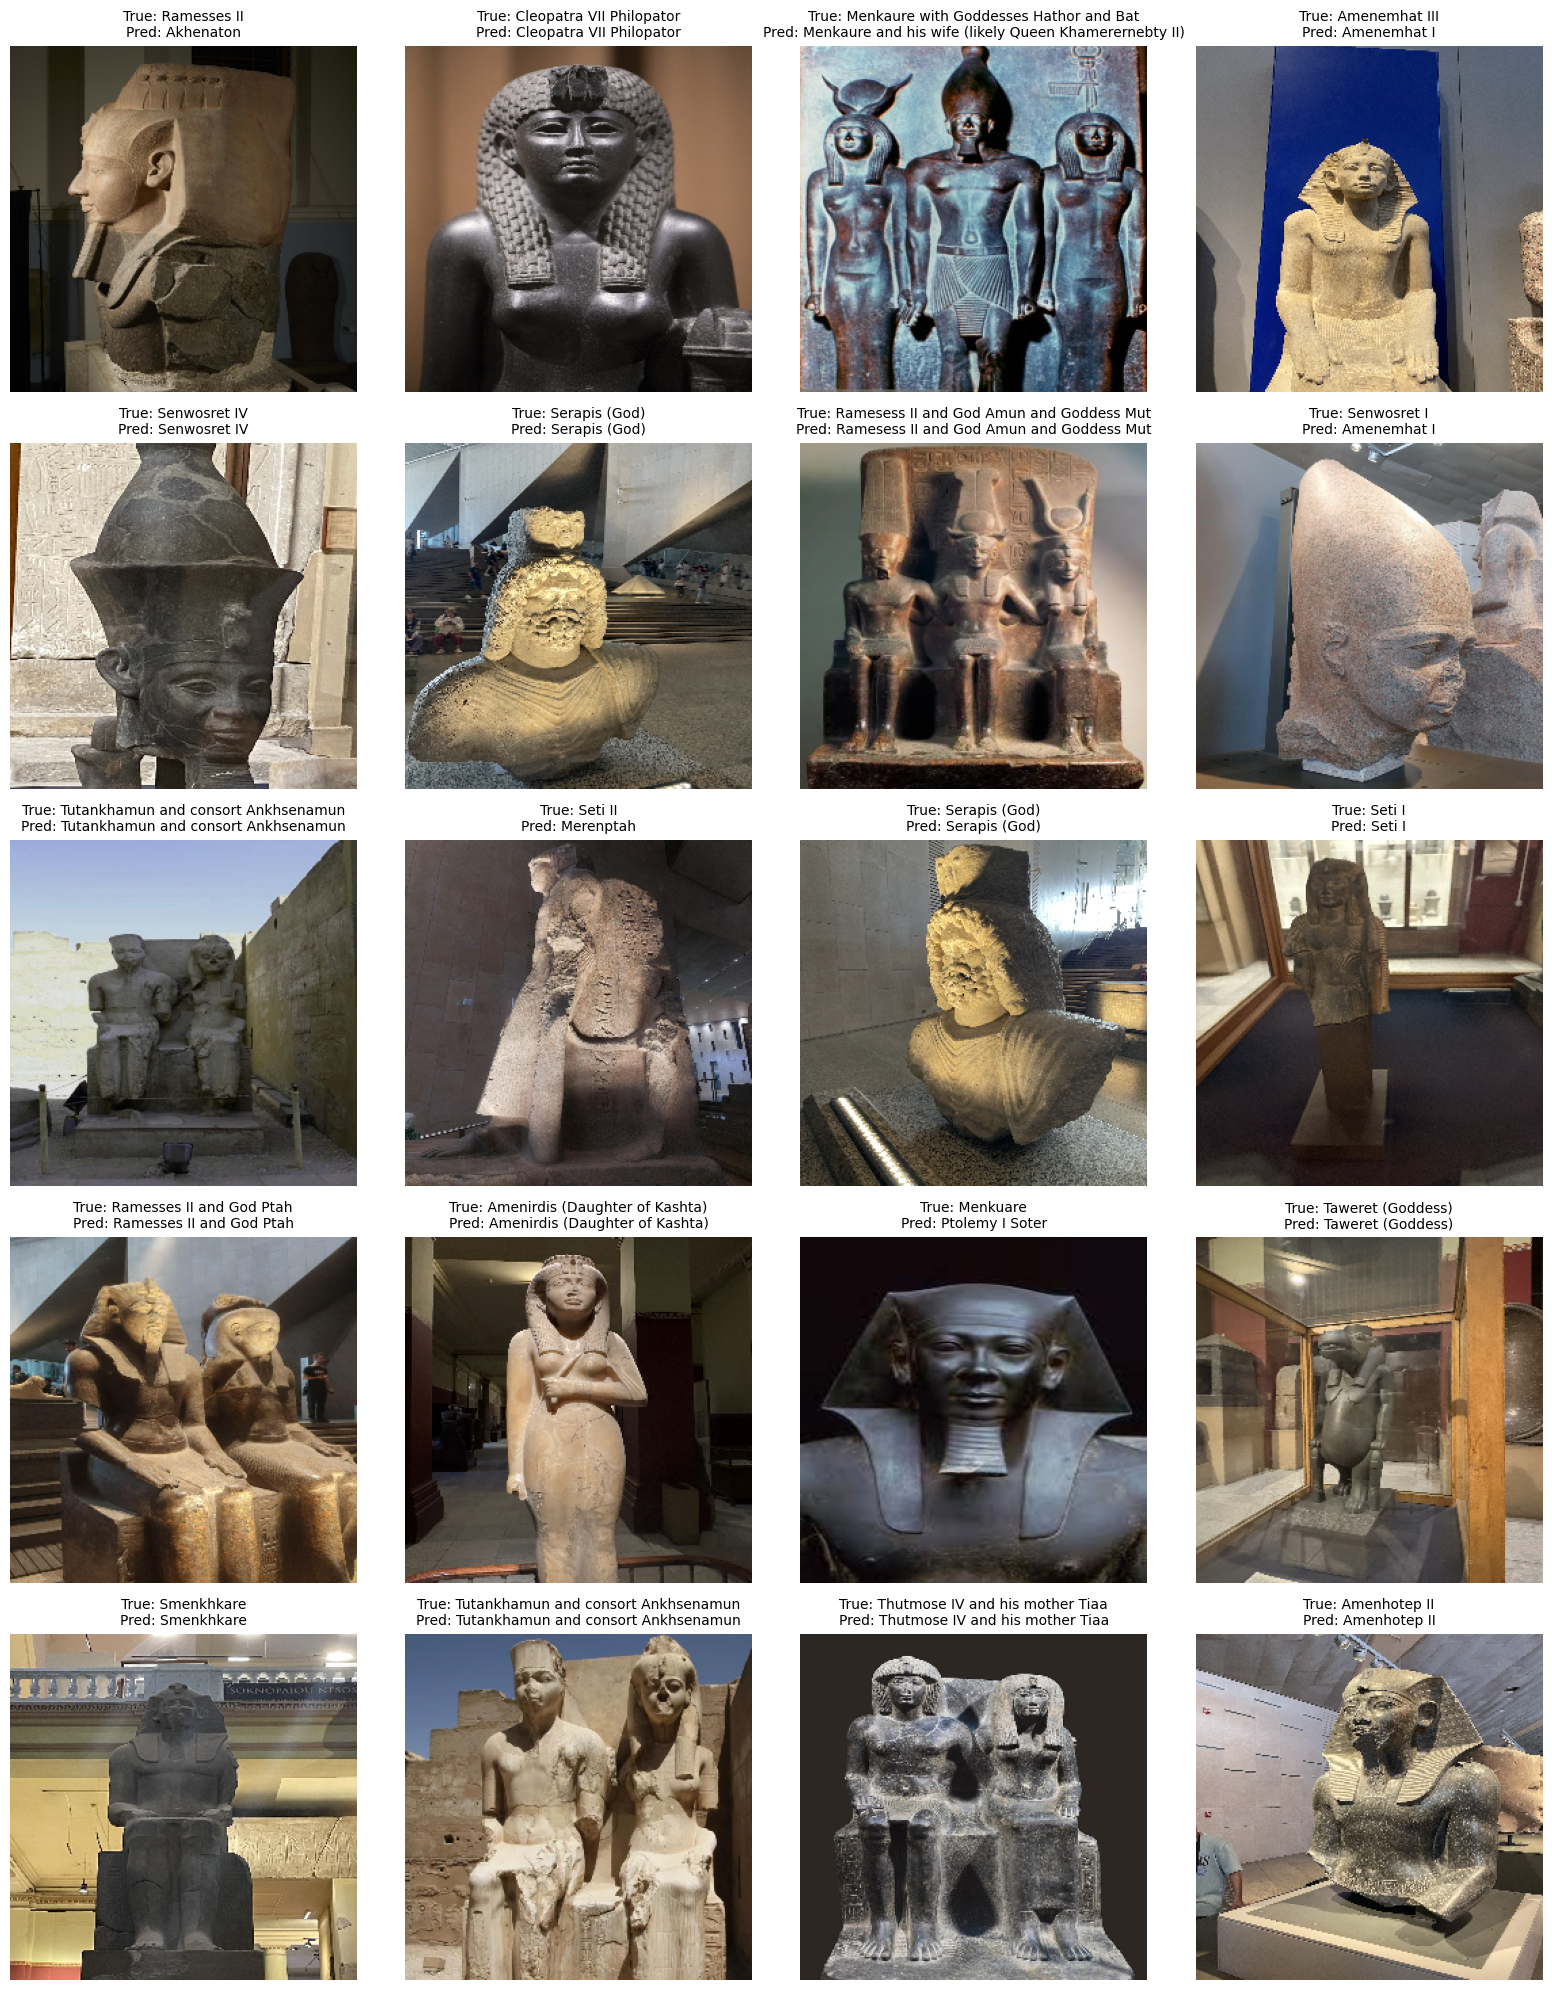

In [ ]:
def display_original_samples(df, model, encoder, image_size=256, n=12):
    samples = df.sample(n)

    cols = 4
    rows = math.ceil(n / cols)

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(samples.iterrows()):
        path = row["path"]
        true_id = int(row["label"])

        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (image_size, image_size))

        x = img_resized.astype(np.float32)
        x = preprocess_input(x)
        x = np.expand_dims(x, axis=0)

        pred = model.predict(x, verbose=0)
        pred_id = np.argmax(pred)

        true_label = encoder.inverse_transform([true_id])[0]
        pred_label = encoder.inverse_transform([pred_id])[0]
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_resized)
        plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_original_samples(test_df, model, encoder, image_size=256, n=20)



In [46]:
import pickle
model.save('/kaggle/working/resnet50_not_aug_oneStageTrain.keras')

encoder_file = "label_encoder_resnet_no_aug_oneStageTrain.pkl"

with open(encoder_file, "wb") as f:
    pickle.dump(encoder, f)